In [96]:
import os  
import gspread
import pandas as pd
from gspread_dataframe import get_as_dataframe
import matplotlib.pyplot as plt
import numpy as np

In [28]:
## establish read-only connection with sheets API
client = gspread.oauth(scopes=gspread.auth.READONLY_SCOPES)

In [29]:
## store spreadsheet id (whole sheet)
SPREADSHEET_ID = "1roNG9nRTXMi1A5uTQxIKDGfMwvnG2DTlUMdCbUxrGjo"

## store ID FOR SPECIFIC TAB
TAB_ID = 957827835

## use that API client to get the spreadsheet and tab
spreadsheet = client.open_by_key(SPREADSHEET_ID)
tab = spreadsheet.get_worksheet_by_id(TAB_ID)


In [35]:
## read in as pandas dataframe
df = get_as_dataframe(tab)

In [44]:
## clean up data
cols = ["timestamp", "email", "name", "python_background", "sql_background",
       "policy_areas", "syllabus_q", "learning_q"]
df.columns = cols
cols_show = [col for col in df.columns if col not in ["email", "name"]]
df[cols_show].head()

,timestamp,python_background,sql_background,policy_areas,syllabus_q,learning_q
0,8/21/2026 12:01:59,Some,Some,"Education, Health",NaN,NaN
1,8/21/2026 13:01:25,None,Some,Monetary Policy,NaN,There are lots of recent computer science unde...
2,8/21/2026 20:23:49,Some,Some,"Criminal justice, Housing, International devel...",NaN,NaN
3,8/21/2026 22:16:11,Some,A lot,"Criminal justice, International development, P...",NaN,NaN
4,8/22/2026 10:47:51,None,None,"Education, Housing, International development",I have been actively trying to figure out this...,I am very nervous about the material since the...


In [66]:
test = df.loc[:, "policy_areas"]
type(test)

pandas.core.series.Series

In [97]:
## visualize policy areas response
FORM_OPTIONS = [
    "Education",
    "Criminal justice",
    "Health",
    "Housing",
    "International development",
    "Climate",
]

CONSOLIDATE_OTHER = {
    "technology": "Technology / AI",
    "tech policy": "Technology / AI",
    "tech and ai": "Technology / AI",
    "science and tech": "Technology / AI",
}

##  split responses at , and strip leading/trailing whitespace
all_areas = (df.loc[:, "policy_areas"].str.split(",")      
        .explode()           
        .str.strip() )

## filter out na and blank
all_areas_filtered = all_areas[all_areas.notna() & (all_areas != "")]

## remap similar others onto same categories
all_areas_consolidate = all_areas_filtered.str.lower() \
                        .map(CONSOLIDATE_OTHER).fillna(all_areas_filtered)

## count by policy area
count_by_area = pd.DataFrame(all_areas_consolidate.value_counts()
                            .rename_axis("policy_areas")
                            .rename("count_students").reset_index()
                            .sort_values(by = "count_students"))
count_by_area

## add grouping of form response or other
count_by_area["type_response"] = np.where(count_by_area.policy_areas.isin(FORM_OPTIONS),
                                "Form Choice",
                                "Other Free Text")


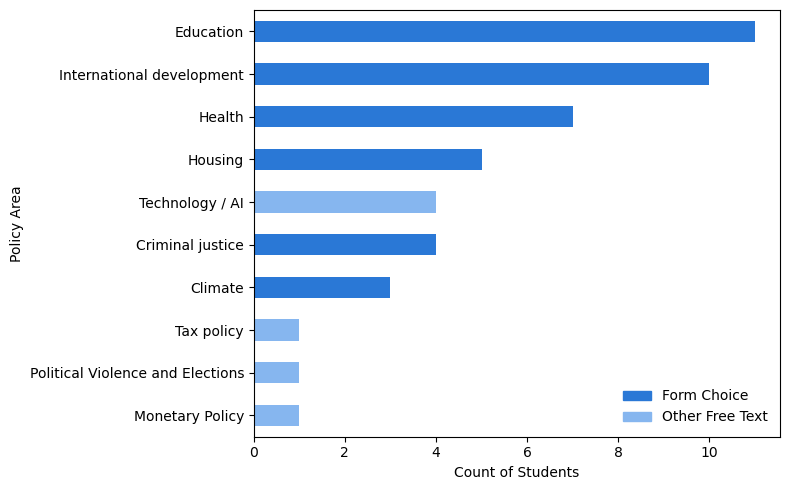

In [102]:
## visualize 
COLORS = {"Form Choice": "#2a78d6", "Other Free Text": "#86b6ef"}
ax = count_by_area.plot.barh(x="policy_areas", y="count_students",
    color= count_by_area["type_response"].map(COLORS).tolist(),
                        figsize=(8, 5), legend=False)
ax.set_xlabel("Count of Students")
ax.set_ylabel("Policy Area")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c, label=t)
                   for t, c in COLORS.items()], frameon=False, loc="lower right")
plt.tight_layout()
plt.savefig("ppol5203_policyareas.png", dpi=200, bbox_inches="tight")